# Data Loading and inspection

In [1]:
import numpy as np
import pandas as pd
df=pd.read_parquet('0000.parquet.1')
df

,text,date,user,sentiment,query
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Mon Apr 06 22:19:45 PDT 2009,_TheSpecialOne_,0,NO_QUERY
1,is upset that he can't update his Facebook by ...,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,0,NO_QUERY
2,@Kenichan I dived many times for the ball. Man...,Mon Apr 06 22:19:53 PDT 2009,mattycus,0,NO_QUERY
3,my whole body feels itchy and like its on fire,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,0,NO_QUERY
4,"@nationwideclass no, it's not behaving at all....",Mon Apr 06 22:19:57 PDT 2009,Karoli,0,NO_QUERY
...,...,...,...,...,...
1599995,Just woke up. Having no school is the best fee...,Tue Jun 16 08:40:49 PDT 2009,AmandaMarie1028,4,NO_QUERY
1599996,TheWDB.com - Very cool to hear old Walt interv...,Tue Jun 16 08:40:49 PDT 2009,TheWDBoards,4,NO_QUERY
1599997,Are you ready for your MoJo Makeover? Ask me f...,Tue Jun 16 08:40:49 PDT 2009,bpbabe,4,NO_QUERY
1599998,Happy 38th Birthday to my boo of alll time!!! ...,Tue Jun 16 08:40:49 PDT 2009,tinydiamondz,4,NO_QUERY


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   text       1600000 non-null  object
 1   date       1600000 non-null  object
 2   user       1600000 non-null  object
 3   sentiment  1600000 non-null  int32 
 4   query      1600000 non-null  object
dtypes: int32(1), object(4)
memory usage: 54.9+ MB


In [3]:
df.isnull().sum()

text         0
date         0
user         0
sentiment    0
query        0
dtype: int64

In [4]:
df['sentiment'].value_counts()

sentiment
0    800000
4    800000
Name: count, dtype: int64

# Sentiment label transformation

In [5]:
df['sentiment']=df['sentiment'].map({0:0,4:1}) # 0 --> Negative and 1 --> Positive
df['sentiment'].value_counts()

sentiment
0    800000
1    800000
Name: count, dtype: int64

# Text Cleaning

In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # URLs
    text = re.sub(r"@\w+|#\w+", "", text)       # mentions & hashtags
    text = re.sub(r"[^a-z\s]", "", text)        # punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()    # extra whitespace
    return text

df["cleaned_text"] = df["text"].apply(clean_text)

# Train Test Split

In [7]:
from sklearn.model_selection import train_test_split
X=df['cleaned_text']
y=df['sentiment']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# TF-IDF Vectorization

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression - Model Training



In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100)
model.fit(X_train_tfidf,y_train)

LogisticRegression()

In [10]:
y_pred=model.predict(X_test_tfidf)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Logistic Regression Performance
Accuracy: 0.812475
Precision: 0.8042340599023939
Recall: 0.82601875
F1-score: 0.8149808530712167


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81    160000
           1       0.80      0.83      0.81    160000

    accuracy                           0.81    320000
   macro avg       0.81      0.81      0.81    320000
weighted avg       0.81      0.81      0.81    320000



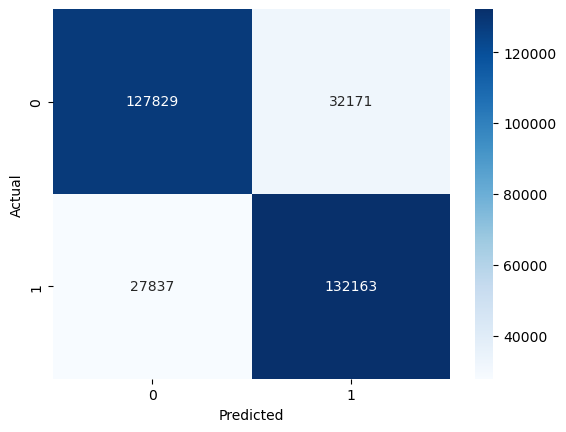

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Coefficient Analysis

In [13]:
features = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

coef_df=pd.DataFrame({
    'feature':features,
    'coefficient':coefficients})

top_positive = coef_df.sort_values(by="coefficient", ascending=False,ignore_index=True).head(20)
top_negative = coef_df.sort_values(by="coefficient", ascending=True,ignore_index=True).head(20)

print("Top Positive Features:\n")
print(top_positive)

print("\nTop Negative Features:\n")
print(top_negative)

Top Positive Features:

            feature  coefficient
0         cant wait    10.926224
1           not bad     8.765961
2        no problem     7.592289
3             smile     7.029745
4            thanks     6.750349
5             happy     6.200284
6   congratulations     5.888797
7             proud     5.606484
8           smiling     5.422502
9           welcome     5.238055
10        wonderful     4.964702
11             hehe     4.955623
12              thx     4.951238
13       no worries     4.891891
14          isnt it     4.867328
15          not too     4.862504
16         congrats     4.772938
17          me know     4.688479
18        hilarious     4.606965
19         pleasure     4.602406

Top Negative Features:

          feature  coefficient
0             sad   -15.169532
1            miss   -10.417323
2           sadly   -10.070866
3            poor    -9.939514
4             rip    -9.591283
5   unfortunately    -9.362072
6       not happy    -9.276999
7         

In [14]:
y_pred_prob = model.predict_proba(X_test_tfidf)
sentiment_score = y_pred_prob[:, 1]

df_test = pd.DataFrame({
    'X_test':X_test,
    'y_test':y_test,
    'y_pred':y_pred,
    'sentiment_score':sentiment_score})

df_test.head()

,X_test,y_test,y_pred,sentiment_score
291262,yes black and red are my fav colors i really w...,0,1,0.810979
1359075,qu buy open house this weekend ampm best value...,1,1,0.791173
1009651,fran can you greet me on air if thats okay hah...,1,1,0.942089
1538714,omg thats awesome goood luck u can meet caaute...,1,1,0.933910
1046690,hahahhaha that is a very good point,1,1,0.866243


In [15]:
def sentiment_bucket(score):
    if score <= 0.4:
        return "Negative"
    elif score <= 0.7:
        return "Neutral"
    else:
        return "Positive"

df_test["sentiment_bucket"] = df_test["sentiment_score"].apply(sentiment_bucket)
df_test.head()

,X_test,y_test,y_pred,sentiment_score,sentiment_bucket
291262,yes black and red are my fav colors i really w...,0,1,0.810979,Positive
1359075,qu buy open house this weekend ampm best value...,1,1,0.791173,Positive
1009651,fran can you greet me on air if thats okay hah...,1,1,0.942089,Positive
1538714,omg thats awesome goood luck u can meet caaute...,1,1,0.933910,Positive
1046690,hahahhaha that is a very good point,1,1,0.866243,Positive


In [16]:
df_test[(df_test['sentiment_bucket']=="Neutral")]

,X_test,y_test,y_pred,sentiment_score,sentiment_bucket
1028760,na its cday over hurr mama,1,1,0.576595,Neutral
240612,whyyyyy were you guys not in vegas last week w...,0,0,0.457816,Neutral
1333503,un gusto,1,1,0.663811,Neutral
1382022,watching quothunt for red octoberquot feet up ...,1,1,0.609956,Neutral
1001933,note to self a sleepy dad is a generous one he...,1,0,0.434524,Neutral
...,...,...,...,...,...
283083,oh yeah that ones cute i forgot to save it,0,1,0.598157,Neutral
688077,only one or two have you read nick daviess fla...,0,1,0.660808,Neutral
124842,i kip yawning from juz nowsian uh,0,1,0.576682,Neutral
109729,it getting booring now more days to go until t...,0,0,0.498825,Neutral


In [17]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(model, "log_reg_model.pkl")

['log_reg_model.pkl']